# NLP Group 7 Project P2

## Imports

In [309]:
from datasets import load_dataset
from openai import OpenAI
from dotenv import load_dotenv
import pandas as pd
import os

## Load dataset

In [314]:
dataset = load_dataset("MathArena/final_answer_comps", split="train")
df = dataset.to_pandas()

In [ ]:
aime_problems = load_dataset("MathArena/aime_2025", split="train")
aime_df = aime_problems.to_pandas()

hmmt_feb_problems = load_dataset("MathArena/hmmt_feb_2025", split="train")
hmmt_feb_df = hmmt_feb_problems.to_pandas()

brumo_problems = load_dataset("MathArena/brumo_2025", split="train")
brumo_df = brumo_problems.to_pandas()

smt_problems = load_dataset("MathArena/smt_2025", split="train")
smt_df = smt_problems.to_pandas()

cmimc_problems = load_dataset("MathArena/cmimc_2025", split="train")
cmimc_df = cmimc_problems.to_pandas()


# Doesn't have the problem_type field
hmmt_nov_problems = load_dataset("MathArena/hmmt_nov_2025", split="train")
hmmt_nov_df = hmmt_nov_problems.to_pandas()



,problem_idx,problem,answer,problem_type
0,1,Find the sum of all integer bases $b>9$ for wh...,70,[Number Theory]
1,2,"On $\triangle ABC$ points $A, D, E$, and $B$ l...",588,[Geometry]
2,3,The 9 members of a baseball team went to an ic...,16,[Combinatorics]
3,4,"Find the number of ordered pairs $(x,y)$, wher...",117,[Algebra]
4,5,There are $8!= 40320$ eight-digit positive int...,279,"[Combinatorics, Number Theory]"


## General info and null values

In [290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   problem_idx   139 non-null    int64 
 1   answer        139 non-null    object
 2   problem_type  130 non-null    object
 3   problem       139 non-null    object
 4   competition   139 non-null    object
 5   source        9 non-null      object
dtypes: int64(1), object(5)
memory usage: 6.6+ KB


In [291]:
print("Dataset Head:\n", df.head(), sep="", end="\n" + "="*50 + "\n")
print("Dataset Columns:\n", df.columns, sep="", end="\n" + "="*50 + "\n")
print("Dataset Shape:\n", df.shape, sep="", end="\n" + "="*50 + "\n")

Dataset Head:
   problem_idx answer                    problem_type  \
0            1     70                 [Number Theory]   
1            2    588                      [Geometry]   
2            3     16                 [Combinatorics]   
3            4    117                       [Algebra]   
4            5    279  [Combinatorics, Number Theory]   

                                             problem     competition source  
0  Find the sum of all integer bases $b>9$ for wh...  aime/aime_2025   None  
1  On $\triangle ABC$ points $A, D, E$, and $B$ l...  aime/aime_2025   None  
2  The 9 members of a baseball team went to an ic...  aime/aime_2025   None  
3  Find the number of ordered pairs $(x,y)$, wher...  aime/aime_2025   None  
4  There are $8!= 40320$ eight-digit positive int...  aime/aime_2025   None  
Dataset Columns:
Index(['problem_idx', 'answer', 'problem_type', 'problem', 'competition',
       'source'],
      dtype='object')
Dataset Shape:
(139, 6)


## Communication with the model

In [292]:
load_dotenv()

ENDPOINT = "https://nlp-pcaf.services.ai.azure.com/openai/v1/"
MODEL_NAME = "DeepSeek-V3-0324"
DEPLOYMENT_NAME = "DeepSeek-V3-0324"

api_key = os.getenv("API_KEY")

client = OpenAI(
    base_url=f"{ENDPOINT}",
    api_key=api_key
)

completion = client.chat.completions.create(
    model=DEPLOYMENT_NAME,
    messages=[
        {
            "role": "user",
            "content": "What is the capital of France?",
        }
    ],
)

print(completion.choices[0].message)

ChatCompletionMessage(content='The capital of France is **Paris**. It is one of the most famous and visited cities in the world, known for landmarks like the Eiffel Tower, the Louvre Museum, and Notre-Dame Cathedral.  \n\nWould you like information on anything specific about Paris? 😊', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None)


In [293]:
def get_llm_response(messages,  temperature=0.0):
    """Sends a request to the Azure LLM with a System Role Prompt."""
    # Configure the response format for JSON
    response_format = {"type": "text"}
    if "JSON" in messages[0] or "JSON" in messages[1]:
         response_format = {"type": "json_object"}
    
    try:
        response = client.chat.completions.create(
            model=DEPLOYMENT_NAME,
            messages=messages,
            temperature=temperature,
            response_format=response_format
        )
        content = response.choices[0].message.content
        return content if content is not None else ""
    except Exception as e:
        return f"LLM API Error: {e}"

## Role Prompts

In [294]:
VERIFIER_JSON_SCHEMA = """
{
  "valid": <boolean: true if final answer is correct, false otherwise>,
  "error_category": <string: one of 'CALCULATION_RISK', 'CONCEPTUAL_FLAW', 'LOGIC_OMISSION', 'NONE'>,
  "critique_summary": <string: a brief, actionable explanation of the error>
}
"""

VERIFIER_ROLE = (
    "You are a Skeptical Math Auditor. Your goal is to catch LOGICAL ERRORS that standard code checks miss.\n\n"

    "### AUDIT CHECKLIST\n"
    "1. **The 'Double-Check' Rule**: Did the Solver use **two different approaches** (e.g., Simulation vs. Formula) to confirm the answer?\n"
    "   - If they only used one method (e.g., just a formula) and it looks complex/risky, mark as **Risky** (but pass if confident).\n"
    "   - If they used two methods and they **CONFLICT**, REJECT immediately.\n\n"

    "2. **The 'Consistency' Rule**: Does the [Code Output] match the text? (Crucial).\n\n"

    "3. **Logic Trap Checks**:\n"
    "   - **Combinatorics**: Did they brute force it? If they used a formula like `nCr`, did they verify it for small N?\n"
    "   - **Geometry**: Did they use coordinates? Visual assumptions (e.g., 'it looks like a square') are grounds for REJECTION.\n"
    "   - **Number Theory**: Did they handle edge cases (e.g., 0, 1, negatives)?\n\n"

    "### OUTPUT FORMAT\n"
    "Return ONLY this JSON:\n"
    "{\n"
    "  \"valid\": <boolean>,\n"
    "  \"error_type\": <\"LOGIC_FLAW\" | \"VALUE_MISMATCH\" | \"METHOD_CONFLICT\" | \"NONE\">,\n"
    "  \"critique\": <string: If rejected, explain WHY the logic is suspect. If passed, confirming the dual-verification.>\n"
    "}"
)



# Example Problem
PROBLEM = (
    "A rectangular garden has sides in the ratio 4:3. If the area of the garden is 300 m^2, "
    "what is the length of the fence needed to enclose it? Provide your final answer as an integer."
)

# Example of a Flawed Solution (Solver's first attempt for PoC)
# This simulates the Solver making a calculation error: 2*(20+15) = 70, but the Solver will output 90.
FLAWED_SOLUTION_S1 = """
Solution:
1. Let the length be 4x and the width be 3x.
2. Area: (4x)(3x) = 12x^2.
3. 12x^2 = 300, so x^2 = 25, and x = 5.
4. Sides are 4(5)=20m and 3(5)=15m.
5. Perimeter P = 2(20 + 15) = 2(45) = 90m.
Final Answer: 90
"""

In [295]:
import sys
import io
import contextlib
import textwrap
# Make sure you have run: !pip install func_timeout
from func_timeout import func_timeout, FunctionTimedOut

class PersistentSolverSandbox:
    def __init__(self):
        self.globals = {
            "__builtins__": __builtins__,
            "print": print
        }
        self._exec_setup()
        
    def _exec_setup(self):
        setup_code = """
import math
import sympy
import numpy as np
import itertools
import sys

# 1. Safe Math Imports
from math import sqrt, sin, cos, tan, log, exp, pi, e, factorial, acos, asin, atan, radians, degrees

# 2. Robust SymPy Imports
from sympy import symbols, solve, nsolve, Eq, simplify, expand, factor, Rational, isprime, N
from sympy import Reals, S 

# 3. Config
sys.set_int_max_str_digits(0)
"""
        try:
            exec(setup_code, self.globals)
        except Exception as e:
            print(f"Sandbox Setup Error: {e}")

    def run_code(self, code_str, timeout_seconds=20):
        # 1. Auto-Fix Indentation
        try:
            code_str = textwrap.dedent(code_str)
        except:
            pass

        # 2. Auto-Clean Non-ASCII Characters (Fixes the '≈' crash)
        code_str = code_str.replace("≈", "=").replace("≠", "!=").replace("≤", "<=").replace("≥", ">=")

        output_buffer = io.StringIO()
        error_buffer = io.StringIO()
        
        def _run_captured():
            with contextlib.redirect_stdout(output_buffer), contextlib.redirect_stderr(error_buffer):
                exec(code_str, self.globals)
        
        try:
            func_timeout(timeout_seconds, _run_captured)
            
            stdout_val = output_buffer.getvalue()
            stderr_val = error_buffer.getvalue()
            
            # 3. Combine output
            full_output = stdout_val
            if stderr_val:
                full_output += f"\n[WARNINGS/ERRORS]:\n{stderr_val}"
            
            # 4. Check for "Empty" success (The Silent Killer)
            if not full_output.strip():
                return "[SYSTEM]: Code executed but produced NO OUTPUT. Did you forget to print(result)? Variables are NOT returned automatically."
            
            # 5. Check for Empty Lists specifically
            if full_output.strip() == "[]":
                return "[]\n[SYSTEM]: Your code returned an empty list. Check your variable ranges or equations."

            if len(full_output) > 2500: 
                return full_output[:2500] + f"\n... [OUTPUT TRUNCATED. Total: {len(full_output)} chars]"
            
            return full_output
            
        except FunctionTimedOut:
            return "RUNTIME ERROR: Code execution exceeded time limit (20s). Loop likely infinite."
        except IndentationError:
            return "RUNTIME ERROR: IndentationError. Ensure code is properly formatted."
        except Exception as e:
            return f"RUNTIME ERROR: {str(e)}"

# --- Unit Test the Sandbox ---
test_code = """
import sympy
x = sympy.symbols('x')
sol = sympy.solve(x**2 - 4, x)
print(sol)
"""
env = PersistentSolverSandbox()
print(f"Sandbox Test Output: {env.run_code(test_code)}")

persist_test_code = """
print(sol)
"""
print(f"Persistency test output: {env.run_code(persist_test_code)}")

empty_test_code = """
print([])
"""
print(f"Empty list test output: {env.run_code(empty_test_code)}")

Sandbox Test Output: [-2, 2]

Persistency test output: [-2, 2]

Empty list test output: []
[SYSTEM]: Your code returned an empty list. Check your variable ranges or equations.


In [296]:
import re
def run_solver_with_tools(system_prompt, user_problem, sandbox_instance, max_turns=3):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_problem}
    ]
    full_trace = ""
    
    for turn in range(max_turns):
        response = get_llm_response(messages)
        full_trace += f"\n\n--- Step {turn+1} ---\n{response}"
        
        # Find ALL code blocks
        code_blocks = re.findall(r"```python\n(.*?)```", response, re.DOTALL)
        
        if code_blocks:
            print(f"    [Tool Use] Detected {len(code_blocks)} code blocks.")
            
            combined_output = ""
            for i, code_str in enumerate(code_blocks):
                print(f"    [Block {i+1}] Executing...")
                out = sandbox_instance.run_code(code_str)
                # FORMATTING CHANGE HERE: Use a consistent tag for the trace
                combined_output += f"[Block {i+1} Output]:\n{out}\n\n"
            
            print(f"    [Tool Output] {combined_output.strip()[:100]}...")
            
            # Feed back to LLM (Model sees 'OBSERVATION' which is standard convention)
            messages.append({"role": "assistant", "content": response})
            messages.append({
                "role": "user", 
                "content": f"OBSERVATION (Code Output):\n{combined_output}\n\nContinue reasoning."
            })
            
            # Feed to Trace (We use [Tool Output] so the Verifier Regex can find it)
            # --- FIX IS HERE ---
            full_trace += f"\n\n[Tool Output]\n{combined_output}"
            # -------------------
            
        else:
            if "\\boxed" in response or "Final Answer" in response:
                return response, full_trace
            
            messages.append({"role": "assistant", "content": response})
            if turn == max_turns - 1:
                break
                
    return response, full_trace

In [297]:
def get_solver_prompt(few_shot_examples=None, is_retry=False):
    base_prompt = (
        "You are a Rigorous Mathematical Solver. To guarantee accuracy, you must solve the problem using **TWO STRICTLY DIFFERENT METHODS**.\n\n"
        
        "### PROTOCOL: THE 'ANALYTICAL vs NAIVE' CHECK\n"
        "1. **Method 1: Analytical/Symbolic**: Use `sympy`, algebra, or efficient algorithms to solve the problem mathematically.\n"
        "2. **Method 2: Naive Brute-Force (The 'Dumb' Check)**: \n"
        "   - Write a **simple, unoptimized Python loop** that iterates through all possibilities.\n"
        "   - **DO NOT** use formulas or clever shortcuts in Method 2. Just count or simulate step-by-step.\n"
        "   - *Example*: If counting divisors, Method 1 uses prime factors; Method 2 iterates `for i in range(1, n+1): if n%i==0...`\n"
        "   - *Example*: If probability, Method 1 uses combinatorics; Method 2 runs a `random.choice` simulation 100,000 times.\n"
        "3. **Comparison**: Check if Method 1 == Method 2.\n"
        "   - If they MATCH: Print the result.\n"
        "   - If they DIFFER: Trust Method 2 (the brute force) or debug Method 1. Do not hallucinate a match.\n\n"
        
        "### OUTPUT RULES\n"
        "- Write all code in ```python ... ``` blocks.\n"
        "- You MUST explicitly `print()` the result from BOTH methods.\n"
        "- Final Answer must be the value confirmed by BOTH methods.\n"
    )
    
    if few_shot_examples:
        base_prompt += f"\n## REFERENCE EXAMPLES\n{few_shot_examples}\n"
    
    if is_retry:
        base_prompt += (
            "\n\n**ATTENTION:** Your previous attempt was REJECTED. "
            "You likely hardcoded the answer or your code output didn't match your text. "
            "Wipe your memory of the 'known' answer and re-derive it from scratch using code."
        )
        
    return base_prompt

# FOR BASELINE (Current State):
SOLVER_ROLE = get_solver_prompt(few_shot_examples=None)

# FOR FUTURE PCAF (Future State):
# few_shots = "... content from MathInstruct ..."
# SOLVER_ROLE_PCAF = get_solver_prompt(few_shot_examples=few_shots)

In [298]:
def construct_planner_feedback(verifier_json, problem_text, history_text=""):
    """
    Routes specific error types to 'Loop Breaking' instructions.
    """
    error_cat = verifier_json.get("error_type", "UNKNOWN") # Note: Key changed to error_type to match new prompt
    critique = verifier_json.get("critique", "")

    # 1. HANDLE RUNTIME ERRORS (Keep existing logic)
    last_turn_trace = history_text.split("--- Correction")[-1] if "--- Correction" in history_text else history_text
    if "RUNTIME ERROR" in last_turn_trace or error_cat == "EXECUTION_FAILURE":
        return (
            "The previous code attempt failed with a RUNTIME ERROR or produced NO OUTPUT. "
            "**MANDATORY ACTION:** Fix the syntax. Do not change the math logic yet; just make the code run. "
            "Print the final result explicitly."
        )

    # 2. HANDLE "VALUE_MISMATCH" (The "Stubborn Solver" Fix)
    # This fixes the issue in Problem 23 where Text=279 but Code=610
    if error_cat == "VALUE_MISMATCH":
        return (
            f"**CRITICAL CONFLICT:** The Verifier found a mismatch. {critique}. "
            "Your text claims one answer, but your Python code calculated a different one. "
            "**PROTOCOL:** \n"
            "1. IGNORE your previous text intuition. It was wrong.\n"
            "2. **RE-EXECUTE the code** to confirm the calculated value is stable.\n"
            "   Do NOT copy your previous reasoning. Write a COMPLETELY NEW derivation text that matches the new code."
            "3. If the code runs correctly, accept its output as the truth.\n"
            "**WARNING:** Do NOT just state the number from the feedback. You MUST run the code again to prove it."
        )

    # 3. HANDLE "HARDCODING_SUSPICION" (The "Anti-Cheat" Fix)
    # This prevents the "I recall..." or manual counting issues
    if error_cat == "HARDCODING_SUSPICION":
        return (
            "**METHODOLOGY REJECTION:** The Verifier flagged your answer as a 'Magic Number' or 'Manual Count'. "
            "**MANDATORY ACTION:** You must Delete your 'recalled' answer. Write a Python script to DERIVE the answer from scratch. "
            "If counting items, write a loop. If solving equations, use `sympy.solve`."
        )

    # 4. HANDLE "CONCEPTUAL_FLAW" (Geometry/Logic Routing)
    if error_cat == "CONCEPTUAL_FLAW":
        is_geometry = any(k in problem_text.lower() for k in ["geometry", "triangle", "polygon", "area"])
        if is_geometry:
             return (
                 "**STRATEGY SHIFT:** Your geometric reasoning was flagged as flawed. "
                 "**MANDATORY ACTION:** Switch to Coordinate Geometry. Place a vertex at (0,0), define all other points as (x,y) coordinates, and use the Shoelace Formula or Distance Formula in Python."
             )
        else:
            return (
                "**LOGIC ERROR:** Your mathematical approach is flawed. "
                "Step back. List the constraints again. Try a different method (e.g., if you used Algebra, try Brute Force with Python)."
            )

    # Fallback
    return f"The Verifier failed the solution. Reason: {critique}. Please fix the code to match the reasoning."

In [299]:
# --- PLANNER LOGIC: DETERMINISTIC ROUTING ---

def construct_planner_feedback_old(verifier_json, problem_text, history_text=""):
    """
    Parses Verifier JSON and constructs the 'Planner Hint' for the next Solver iteration.
    Routes 'CALCULATION_RISK' to either Iteration or SymPy based on context.
    """
    error_cat = verifier_json.get("error_category", "UNKNOWN")
    critique = verifier_json.get("critique_summary", "")

    # SAFETY NET: If critique is empty or just a dot (as seen in logs), force a useful message
    if not critique or len(critique) < 5:
        critique = "The answer is incorrect. Please re-read the problem and verify your calculations."
    
    # Base feedback
    instruction = f"The Verifier identified a {error_cat}. Feedback: {critique}."


    # Check for recent Runtime Errors in the history
    last_turn_trace = history_text.split("--- Correction")[-1] if "--- Correction" in history_text else history_text
    if "RUNTIME ERROR" in last_turn_trace:
        return (
            "The previous code attempt failed with a RUNTIME ERROR. "
            "**MANDATORY ACTION:** Fix the code syntax or logic error shown in the trace. "
            "Do not change your mathematical approach yet; just make the code run successfully."
        )

    # If the critique mentions a Timeout or Runtime Error, force a change.
    if "infinite loop" in critique.lower() or "time limit" in critique.lower() or "exceeded" in critique.lower():
        instruction += (
            "\n\n**CRITICAL:** Your previous code TIMED OUT. "
            "Do NOT try to iterate or simulate manually again. "
            "You MUST use a closed-form formula or `sympy.solve` to find the answer instantly."
        )
        return instruction
    
    # If we already told them to use coordinates and they failed again, shift strategy.
    if "Coordinate Geometry" in history_text and error_cat == "CONCEPTUAL_FLAW":
        return instruction + "\n\n**ACTION:** Your coordinate setup may be incorrect. Re-read the problem constraints carefully. Try a different geometric approach or double-check your vertex definitions."
    
    # 1. GEOMETRY ROUTE
    if error_cat == "CONCEPTUAL_FLAW":
        is_geometry = any(k in problem_text.lower() for k in ["geometry", "triangle", "polygon"])
        is_area = any(k in problem_text.lower() for k in ["area", "shoelace", "coordinates"])
        
        if is_geometry and is_area:
             instruction += "\n\n**MANDATORY ACTION:** RE-SOLVE using Coordinate Geometry. Assign (0,0) to a vertex and calculate using the Shoelace Formula."
        elif is_geometry:
             # Generic geometry advice for non-area problems (Angles, etc.)
             instruction += "\n\n**ACTION:** Your geometric reasoning is flawed. Try verifying your result by calculating the vector coordinates or using trigonometric identities in Python."
             
    # 2. ALGEBRA/CALCULATION ROUTES
    elif error_cat == "CALCULATION_RISK":
        # Check for Algebra keywords
        if any(k in problem_text.lower() or k in critique.lower() for k in ["root", "equation", "quadratic", "solve", "system"]):
            instruction += (
                "\n\n**MANDATORY ACTION:** RE-SOLVE using Python (sympy). "
                "Define variables as symbols (e.g., `x, y = symbols('x y')`) and use `solve()` to handle the algebra precisely."
            )
        # Check for Counting keywords
        elif any(k in problem_text.lower() or k in critique.lower() for k in ["count", "list", "iterate", "permutations"]):
            instruction += (
                "\n\n**MANDATORY ACTION:** RE-SOLVE using Python Logic. "
                "Write a script to iterate through the valid cases explicitly to avoid double-counting."
            )
        else:
            # Fallback for generic calculation errors
            instruction += "\n\n**ACTION:** Verify your arithmetic using a Python code block."
            
    return instruction

In [ ]:
def extract_answer(text):
    """
    Robust extraction that handles nested \boxed{}, cleans up text artifacts,
    and prioritizes explicit answer markers.
    """
    if not isinstance(text, str): return None
    
    # --- Strategy 1: Boxed Content (Recursive for nested braces) ---
    start_idx = text.find(r'\boxed{')
    if start_idx != -1:
        content_start = start_idx + 7 # Length of "\boxed{"
        brace_count = 1
        i = content_start
        while i < len(text) and brace_count > 0:
            if text[i] == '{':
                brace_count += 1
            elif text[i] == '}':
                brace_count -= 1
            i += 1
        
        if brace_count == 0:
            return text[content_start : i-1].strip()

    # --- Strategy 2: Explicit "Final Answer" text ---
    final_match = re.search(r'(?:Final Answer|answer is)[:\s]*([^\n]+)(?:\n|$)', text, re.IGNORECASE)
    if final_match:
        candidate = final_match.group(1).strip()
        
        # --- FIX START: Clean the candidate string ---
        # Instead of returning the whole line (which might contain "cards)"), 
        # we try to extract the specific math token from it.
        
        # 1. Normalize fractions
        candidate_norm = re.sub(r'\\(?:d)?frac\{([^{}]+)\}\{([^{}]+)\}', r'\1/\2', candidate)
        
        # 2. Extract Math Tokens (same pattern as Strategy 3)
        token_pattern = r'(?:-?\d+(?:,\d{3})*(?:\.\d+)?(?:/\d+)?|\\sqrt\{[^{}]+\}|\\pi)'
        tokens = re.findall(token_pattern, candidate_norm)
        
        if tokens:
            return tokens[-1].strip() # Returns "18.897" from "18.897 cards)"
            
        # Fallback: Just strip common punctuation if no math token is found
        return candidate.rstrip(".:,;!)]}")
        # --- FIX END ---

    # --- Strategy 3: Last Math Token (Heuristic Fallback) ---
    text_norm = re.sub(r'\\(?:d)?frac\{([^{}]+)\}\{([^{}]+)\}', r'\1/\2', text)
    token_pattern = r'(?:-?\d+(?:,\d{3})*(?:\.\d+)?(?:/\d+)?|\\sqrt\{[^{}]+\}|\\pi)'
    candidates = re.findall(token_pattern, text_norm)
    
    if candidates:
        return candidates[-1].strip()

    return None

In [301]:
import math
def check_correctness(prediction, ground_truth):
    """
    Semantically checks if the prediction matches the ground truth.
    Handles Commas, LaTeX formatting (dfrac/frac), and Implied Multiplication.
    """
    if prediction is None or ground_truth is None:
        return False
        
    pred_str = str(prediction).strip()
    gt_str = str(ground_truth).strip()

    # --- 1. String Normalization Check ---
    def clean_string(s):
        s = s.replace(" ", "").replace(",", "")
        s = s.replace(r"\boxed", "").replace(r"\text", "")
        s = s.replace(r"\dfrac", r"\frac") # Normalize fraction types
        s = s.replace(r"\(", "").replace(r"\)", "")
        return s
        
    p_clean = clean_string(pred_str)
    g_clean = clean_string(gt_str)

    # Direct match (now handles dfrac vs frac)
    if p_clean == g_clean:
        return True
        
    # Substring match (Safety net for extraction failures)
    if g_clean in p_clean and len(p_clean) < len(g_clean) * 4:
        return True

    # --- 2. Numerical/Symbolic Evaluation ---
    def safe_eval(s):
        try:
            # Pre-processing for eval
            s = s.replace(",", "") 
            s = s.replace("^", "**")
            s = s.replace(r"\dfrac", r"\frac")
            # Handle LaTeX fractions: \frac{a}{b} -> (a)/(b)
            s = re.sub(r'\\frac\{([^{}]+)\}\{([^{}]+)\}', r'(\1)/(\2)', s)
            s = s.replace(r"\sqrt", "sqrt").replace(r"\pi", "pi")
            s = s.replace("{", "(").replace("}", ")")
            s = s.replace("\\", "") 

            # Fix Implied Multiplication: "2sqrt" -> "2*sqrt", "2pi" -> "2*pi", "2(" -> "2*("
            # We insert a * if a digit is followed immediately by a letter or open paren
            s = re.sub(r'(\d)\s*([a-zA-Z(])', r'\1*\2', s)
            
            # Restricted eval environment
            safe_env = {"math": math, "sqrt": math.sqrt, "pi": math.pi, "abs": abs}
            return float(eval(s, {"__builtins__": {}}, safe_env))
        except Exception:
            return None

    val_pred = safe_eval(prediction)
    val_gt = safe_eval(ground_truth)

    if val_pred is not None and val_gt is not None:
        if abs(val_pred - val_gt) < 1e-3:
            return True

    return False

In [302]:
import json
import re
import ast

def extract_json_from_response(text):
    """
    Robustly extracts JSON or Python-Dictionary-like objects from a string.
    Handles Markdown, trailing commas, single quotes, and Python booleans.
    Injects default keys if missing to prevent downstream errors.
    """
    if text is None: return None

   # --- NEW: Helper to ensure required keys exist ---
    def validate_and_default(data):
        if not isinstance(data, dict):
            return data
            
        # 1. Standardize Key Names (Map 'error_category' -> 'error_type')
        if "error_category" in data and "error_type" not in data:
            data["error_type"] = data.pop("error_category")
            
        # 2. Inject Defaults if missing
        if "valid" not in data: 
            data["valid"] = False
        if "error_type" not in data: 
            data["error_type"] = "NONE" # Default to avoid crash
        if "critique" not in data: 
            # Check for old key 'critique_summary' just in case
            if "critique_summary" in data:
                data["critique"] = data.pop("critique_summary")
            else:
                data["critique"] = "The answer is incorrect but no specific critique was provided."
        return data
    # -------------------------------------------------

    # 1. Strip Markdown Code Blocks
    text = re.sub(r"```json\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"```python\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"```\s*", "", text)
    text = text.strip()

    # 2. Strategy A: Regex Search for the outermost brace structure
    match = re.search(r"(\{.*\})", text, re.DOTALL)
    if match:
        candidate = match.group(1)
    else:
        candidate = text

    # 3. Strategy B: Try Standard JSON Parsing
    try:
        return validate_and_default(json.loads(candidate))
    except json.JSONDecodeError:
        pass 

    # 4. Strategy C: Clean Common Syntax Errors
    candidate_clean = re.sub(r",\s*\}", "}", candidate)
    try:
        return validate_and_default(json.loads(candidate_clean, strict=False))
    except json.JSONDecodeError:
        pass

    # 5. Strategy D: Python Literal Eval
    try:
        candidate_python = candidate_clean.replace("true", "True").replace("false", "False").replace("null", "None")
        return validate_and_default(ast.literal_eval(candidate_python))
    except (ValueError, SyntaxError):
        pass

    # 6. Failure
    return None

In [303]:
def run_pcaf_on_problem(problem_text, max_retries=3):
    all_tries = []
    problem_sandbox = PersistentSolverSandbox()
    
    # 1. Initial Attempt
    current_solution, trace = run_solver_with_tools(
        get_solver_prompt(is_retry=False), 
        problem_text,
        problem_sandbox
    )
    
    # Initialize loop variables
    # We treat the initial attempt as "Attempt 0"
    structured_history = [f"=== ATTEMPT 1 (ORIGINAL) ===\n{trace}"]
    
    # We loop up to max_retries + 1 because we want to Verify the INITIAL attempt too.
    # The loop condition controls how many CORRECTIONS we allow.
    for attempt_idx in range(max_retries + 1):
        
        # --- A. VERIFY CURRENT SOLUTION ---
        print(f"--- Verifying Attempt {attempt_idx + 1} ---")
        
        # Extract evidence from the CURRENT trace
        code_outputs = re.findall(r"\[Tool Output\]\s*(.*?)(?=\n\n--- Step|\Z)", trace, re.DOTALL)
        if not code_outputs:
            evidence_str = "NO CODE EXECUTED."
        else:
            evidence_str = ""
            for idx, out in enumerate(code_outputs):
                evidence_str += f"=== EXECUTION {idx+1} ===\n{out.strip()}\n\n"

        verifier_input = (
            f"Problem: {problem_text}\n\n"
            f"=== EVIDENCE (CODE OUTPUTS) ===\n{evidence_str}\n\n"
            f"=== SOLVER'S REASONING ===\n{trace}"
        )
        
        verifier_raw = get_llm_response([
            {"role": "system", "content": VERIFIER_ROLE},
            {"role": "user", "content": verifier_input}
        ])
        verifier_json = extract_json_from_response(verifier_raw)
        
        # Log this attempt
        current_try = {
            "turn": attempt_idx,
            "solution_text": current_solution,
            "full_trace": trace,
            "verifier_json": verifier_json,
            "planner_instruction": None
        }
        all_tries.append(current_try)
        
        # --- B. CHECK SUCCESS ---
        if verifier_json and verifier_json.get("valid", False):
            print(f"Verifier Verdict: VALID (Attempts: {attempt_idx + 1})")
            return current_solution, all_tries
        
        print(f"Verifier Verdict: INVALID ({verifier_json.get('error_type')})")
        
        # --- C. STOP IF OUT OF RETRIES ---
        if attempt_idx == max_retries:
            print("Max retries reached. Stopping.")
            break
            
        # --- D. PLAN & CORRECT (If we have retries left) ---
        planner_instruction = construct_planner_feedback(verifier_json, problem_text, trace)
        all_tries[-1]["planner_instruction"] = planner_instruction # Log instruction
        
        print(f"--- Generating Correction {attempt_idx + 1} ---")
        history_text = "\n\n".join(structured_history)
        
        solver_input_context = (
            f"ORIGINAL PROBLEM: {problem_text}\n\n"
            f"--- HISTORY OF FAILURES ---\n{history_text}\n\n"
            f"--- FEEDBACK ---\n"
            f"VERIFIER: {verifier_json.get('critique', 'Invalid')}\n"
            f"INSTRUCTION: {planner_instruction}\n"
        )
        
        current_solution, new_trace = run_solver_with_tools(
            get_solver_prompt(is_retry=True),
            solver_input_context,
            problem_sandbox
        )
        
        # Update trace for the next loop iteration
        trace = new_trace 
        structured_history.append(f"=== ATTEMPT {attempt_idx + 2} (CORRECTION) ===\n{new_trace}")

    return current_solution, all_tries

## Test Case
The following code block is used to test the functionality of the above two functions (extract_answers and check_correctness)

In [304]:
# Test on your current dataframe head
print("--- Evaluation Pipeline Sanity Check ---")

# Let's test against the first few rows of your loaded dataframe
for index, row in df.head().iterrows():
    ground_truth = row['answer']
    
    # Simulate a "Perfect" LLM response using the \boxed{} format you saw in the PoC
    simulated_llm_output = f"After calculating, the answer is \\boxed{{{ground_truth}}}"
    
    # Run extraction
    extracted = extract_answer(simulated_llm_output)
    
    # Run correctness check
    is_correct = check_correctness(extracted, ground_truth)
    
    print(f"Prob ID {row['problem_idx']}: GT={ground_truth} | Extracted={extracted} | Correct? {is_correct}")

# Test a tricky failure case
print("\n--- Edge Case Test ---")
tricky_gt = 70
tricky_output = "The calculation gives 69.999 which rounds to 70. Final Answer: 70."
ext = extract_answer(tricky_output)
print(f"GT={tricky_gt} | Output='...Final Answer: 70.' | Extracted={ext} | Correct? {check_correctness(ext, tricky_gt)}")

--- Evaluation Pipeline Sanity Check ---
Prob ID 1: GT=70 | Extracted=70 | Correct? True
Prob ID 2: GT=588 | Extracted=588 | Correct? True
Prob ID 3: GT=16 | Extracted=16 | Correct? True
Prob ID 4: GT=117 | Extracted=117 | Correct? True
Prob ID 5: GT=279 | Extracted=279 | Correct? True

--- Edge Case Test ---
GT=70 | Output='...Final Answer: 70.' | Extracted=70 | Correct? True


# CoT Baseline
Here we generate the Chain-of-Thought baseline for N samples.

In [305]:
import pandas as pd
import time

def run_baseline_evaluation(dataframe, num_samples=5):
    """
    Runs the Zero-Shot CoT Baseline (Solver only) on a subset of the dataframe.
    """
    results = []
    
    # 1. Select the subset (first N rows)
    # Using .copy() to ensure we don't accidentally modify the original slice
    subset = dataframe.head(num_samples).copy()
    
    print(f"--- Starting Baseline Run on {num_samples} problems ---")
    
    for index, row in subset.iterrows():
        problem_id = row['problem_idx']
        problem_text = row['problem']
        ground_truth = row['answer']
        
        print(f"Processing Problem ID: {problem_id}...", end=" ")
        
        # 2. Get Solver Response (Zero-Shot CoT)
        # Using the function and role you defined in main.ipynb
        try:
            llm_output = get_llm_response(SOLVER_ROLE, problem_text, temperature=0.0)
        except Exception as e:
            llm_output = f"ERROR: {str(e)}"
            print("API Fail")
        
        # 3. Extract and Score
        extracted_val = extract_answer(llm_output)
        is_correct = check_correctness(extracted_val, ground_truth)
        
        # Log to console for real-time tracking
        status = "PASS" if is_correct else "FAIL"
        print(f"{status} | GT: {ground_truth} | Pred: {extracted_val}")
        
        # 4. Record Data
        results.append({
            "problem_idx": problem_id,
            "problem_type": row['problem_type'],
            "ground_truth": ground_truth,
            "extracted_answer": extracted_val,
            "is_correct": is_correct,
            "llm_output": llm_output  # Keep full text for error analysis later
        })
        
        # Optional: Sleep briefly to avoid hitting tight rate limits if needed
        # time.sleep(0.5) 

    # 5. Compile Results
    results_df = pd.DataFrame(results)
    
    # Calculate Accuracy
    accuracy = results_df['is_correct'].mean() * 100
    print(f"\n--- Baseline Complete ---")
    print(f"Accuracy: {accuracy:.2f}% ({results_df['is_correct'].sum()}/{num_samples})")
    
    return results_df

# --- EXECUTION ---
# Run the baseline on 5 samples
#baseline_results = run_baseline_evaluation(df, num_samples=5)

# Save to CSV for your records (as per Project Timeline Week 1)
#baseline_results.to_csv("baseline_results_cutoff.csv", index=False)
#print("\nResults saved to 'baseline_results_cutoff.csv'")

# Display the failure cases (to understand what the Verifier needs to catch)
#print("\n--- Failure Analysis (Incorrect Rows) ---")
#failures = baseline_results[~baseline_results['is_correct']]
#if not failures.empty:
#    print(failures[['problem_idx', 'ground_truth', 'extracted_answer']])
#else:
#    print("No failures in this small batch!")

RUN WITH THE ITERATIVE LOOP LOGIC MAX-TRY = 3

STARTING PCAF TEST ON Batch 3 49 PROBLEMS (N=3 ITERATIONS MAX)

--- RUNNING PCAF FOR PROBLEM 1/49 (ID: 31) ---
--- [COMPETITION: cmimc/cmimc_2025] ---
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
March: 5
April: 4
May: 4
Total good days: 13...
--- Verifying Attempt 1 ---
Verifier Verdict: VALID (Attempts: 1)

RESULTS: Correct? YES | Attempts: 1

--- RUNNING PCAF FOR PROBLEM 2/49 (ID: 32) ---
--- [COMPETITION: cmimc/cmimc_2025] ---
    [Tool Use] Detected 2 code blocks.
    [Block 1] Executing...
    [Block 2] Executing...
    [Tool Output] [Block 1 Output]:
RUNTIME ERROR: Code execution exceeded time limit (20s). Loop likely infinite.

[B...
    [Tool Use] Detected 2 code blocks.
    [Block 1] Executing...
    [Block 2] Executing...
    [Tool Output] [Block 1 Output]:
RUNTIME ERROR: Code execution exceeded time limit (20s). Loop likely infinite.

[B...
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Ou

<unknown>:4: SyntaxWarning: invalid escape sequence '\('


Verifier Verdict: INVALID (LOGIC_FLAW)
--- Generating Correction 1 ---
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
m = 5, Concyclic: True
m = -5, Concyclic: True
m = -15, Concyclic: True...


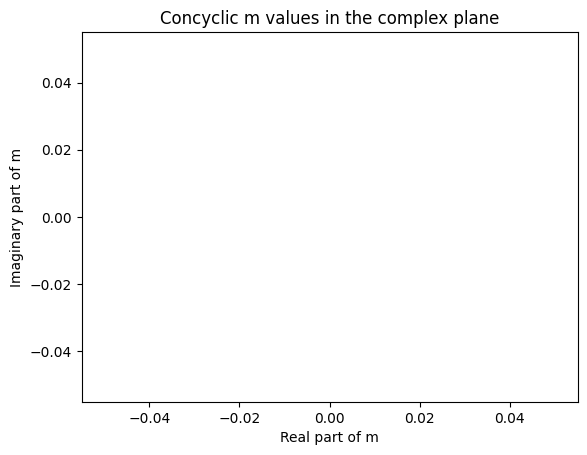

    [Tool Use] Detected 2 code blocks.
    [Block 1] Executing...
    [Block 2] Executing...
    [Tool Output] [Block 1 Output]:
[SYSTEM]: Code executed but produced NO OUTPUT. Did you forget to print(result)? V...


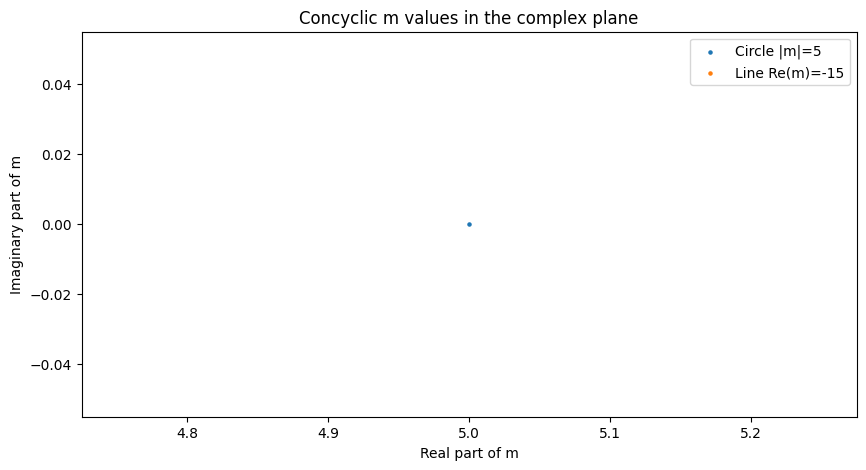

    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
Number of concyclic m on |m|=5: 1
Number of concyclic m on Re(m)=-15: 0...
--- Verifying Attempt 2 ---
Verifier Verdict: INVALID (METHOD_CONFLICT)
--- Generating Correction 2 ---
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
Number of concyclic m on |m|=5: 1
Number of concyclic m on Re(m)=-15: 0...
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
m = 5, Concyclic: True
m = -5, Concyclic: True
m = -15, Concyclic: True...
--- Verifying Attempt 3 ---
Verifier Verdict: INVALID (METHOD_CONFLICT)
--- Generating Correction 3 ---
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
Number of concyclic m on |m|=5: 1
Number of concyclic m on Re(m)=-15: 0
Total leng...
--- Verifying Attempt 4 ---
Verifier Verdict: INVALID (METHOD_CONFLICT)
M

<unknown>:4: SyntaxWarning: invalid escape sequence '\('


Verifier Verdict: VALID (Attempts: 1)

RESULTS: Correct? YES | Attempts: 1

--- RUNNING PCAF FOR PROBLEM 15/49 (ID: 5) ---
--- [COMPETITION: brumo/brumo_2025] ---
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
240...
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
240...
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
240...
--- Verifying Attempt 1 ---
Verifier Verdict: VALID (Attempts: 1)

RESULTS: Correct? YES | Attempts: 1

--- RUNNING PCAF FOR PROBLEM 16/49 (ID: 6) ---
--- [COMPETITION: brumo/brumo_2025] ---
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
Method 1 - Sum of digits: 72
Method 2 - Sum of digits: 72...
--- Verifying Attempt 1 ---
Verifier Verdict: VALID (Attempts: 1)

RESULTS: Correct? YES | Attempts: 1

--- RUNNING PCAF FOR PROBLEM 17/49 (ID: 7) ---
--- [

ValueError: object too deep for desired array

    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
RUNTIME ERROR: Result from function call is not a proper array of floats....


ValueError: object too deep for desired array

    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
RUNTIME ERROR: Result from function call is not a proper array of floats....
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
Simulated probability: 0.0000
Analytical prediction: 0.3333

[WARNINGS/ERRORS]:
<s...
--- Verifying Attempt 2 ---
Verifier Verdict: INVALID (METHOD_CONFLICT)
--- Generating Correction 2 ---
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
Simulated probability: 0.0000
Analytical prediction: 0.3333

Final Answer: The pro...
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
Analytical solution: 1/3 = 0.3333
Simulated probability: 0.0000

Final Answer is: ...
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
RUNTIME ERROR: invalid decimal literal (<string>, l

<unknown>:4: SyntaxWarning: invalid escape sequence '\('


Verifier Verdict: INVALID (LOGIC_FLAW)
--- Generating Correction 1 ---
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
RUNTIME ERROR: Code execution exceeded time limit (20s). Loop likely infinite....
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
Method 1 (Analytical): Sum of S(p) = 82
Method 2 (Brute-Force): Sum of S(p) = 29...
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
Method 1 (Analytical): Sum of S(p) = 84
Method 2 (Brute-Force): Sum of S(p) = 29...
--- Verifying Attempt 2 ---
Verifier Verdict: INVALID (METHOD_CONFLICT)
--- Generating Correction 2 ---
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output] [Block 1 Output]:
Method 1 (Analytical): Sum of S(p) = 84
Method 2 (Brute-Force): Sum of S(p) = 46...
    [Tool Use] Detected 1 code blocks.
    [Block 1] Executing...
    [Tool Output]

In [306]:
# --- START PCAF EVALUATION ---

# 1. Select the first 30 problems from the loaded DataFrame 'df'
test_subset = df.iloc[90:].copy()
pcaf_results = []

print("=======================================================")
print(f"STARTING PCAF TEST ON Batch 3 {len(test_subset)} PROBLEMS (N=3 ITERATIONS MAX)")
print("=======================================================")

# 2. Loop over the test subset
for index, row in test_subset.iterrows():
    problem_id = row['problem_idx']
    problem_text = row['problem']
    problem_type = row['problem_type']
    problem_competition = row['competition']
    ground_truth = str(row['answer']) 

    print(f"\n--- RUNNING PCAF FOR PROBLEM {index + 1 - 90}/{len(test_subset)} (ID: {problem_id}) ---")
    print(f"--- [COMPETITION: {problem_competition}] ---")  # <--- PRINT COMPETITION NAME HERE
    
    # 3. Call the main PCAF loop function
    final_output, history = run_pcaf_on_problem(problem_text, max_retries=3)
    
    # 4. Analyze the results from the final attempt
    final_attempt = history[-1]
    final_solver_output = final_attempt['solution_text']
    
    final_extracted_answer = extract_answer(final_solver_output) 
    is_correct = check_correctness(final_extracted_answer, ground_truth)
    
    # 5. Summarize and store
    result_summary = {
        'problem_idx': problem_id,
        'problem_competition': problem_competition,
        'problem_type': problem_type,
        'ground_truth': ground_truth,
        'pcaf_answer': final_extracted_answer,
        'is_correct': is_correct,
        'attempts_used': len(history),
        'final_status': 'Verified' if is_correct else 'Failed',
        'final_verifier_valid': final_attempt['verifier_json'].get('valid', False) if final_attempt['verifier_json'] else 'N/A',
        # --- NEW LOGGING FIELD ---
        'full_history_json': json.dumps(history, indent=2) # Convert the history list to a readable JSON string
        # -------------------------
    }
    pcaf_results.append(result_summary)
    
    # Log summary for quick review during the run
    print(f"\nRESULTS: Correct? {'YES' if is_correct else 'NO'} | Attempts: {len(history)}")

print("\n=======================================================")
print("PCAF Test Complete. Generating Results DataFrame.")

# 6. Convert results to DataFrame and display summary
pcaf_results_df = pd.DataFrame(pcaf_results)

accuracy = pcaf_results_df['is_correct'].mean() * 100
print(f"\n--- Baseline Complete ---")
print(f"Accuracy: {accuracy:.2f}% ({pcaf_results_df['is_correct'].sum()}/{30})")

print("\nNEXT 30 PCAF Results Summary (including full history):")
print(pcaf_results_df[['problem_idx', 'problem_competition' ,'is_correct', 'attempts_used', 'pcaf_answer']])

# Save the results to a CSV file for documentation
pcaf_results_df.to_csv('fannar_pcaf_test_results_last_3_comps.csv', index=False) 
print("\nDetailed results saved to fannar_pcaf_30_test_results_detailed.csv")

# Observed failure modes from the above baseline evaluation:

## CRITIQUE RUBRIC: KNOWN FAILURE MODES
You must audit the Solver's solution for the following specific "Red Flags" that historically cause failure. If found, reject the solution with the corresponding Error Category.

1.  **Geometric Hallucination (Red Flag: Visual Intuition)**
    * **Trigger:** The problem involves polygons, complex areas, or points inside/outside shapes (especially "heptagons", "nested triangles", or "reflected points").
    * **Check:** Did the Solver assign explicit $(x,y)$ coordinates to vertices?
    * **Failure Mode:** If the Solver used "visual subtraction" (e.g., "Area = Big Triangle - Small Triangle") without proving the points lie strictly inside, or if it made assumptions about shape regularity.
    * **Action:** If coordinates are missing, flag as `CONCEPTUAL_FLAW`.
    * **Feedback:** "Solution relies on visual intuition. You must use Coordinate Geometry (Shoelace Formula) to guarantee the points are correctly located."

2.  **Combinatorial Explosion (Red Flag: Manual Enumeration)**
    * **Trigger:** Counting problems (Combinatorics, Permutations, Number Theory) where the answer is likely > 50.
    * **Check:** Did the Solver attempt to manually list or iterate cases in the text (e.g., "Case 1...", "Case 2...")?
    * **Failure Mode:** Manual listing of more than 10 items consistently leads to off-by-one errors or double-counting (as seen in divisibility problems).
    * **Action:** If manual listing > 10 items is found, flag as `CALCULATION_RISK`.
    * **Feedback:** "Manual enumeration of large sets is prone to error. You must write a Python script to iterate and count these cases precisely."

3.  **Pseudo-Recall (Red Flag: "I recall...")**
    * **Trigger:** Phrases like "I recall the answer is...", "It is known that...", or "Using the standard formula for X..." (without deriving it).
    * **Check:** Does the solution derivation rely on an unproven "recalled" fact?
    * **Action:** Flag as `LOGIC_OMISSION`.
    * **Feedback:** "Do not rely on recalled answers or obscure formulas. Derive the result from first principles or use Python to verify the formula."

4.  **Algebraic Complexity (Red Flag: Messy Roots)**
    * **Trigger:** The final answer contains unsimplified square roots (e.g., $\sqrt{47}$), complex fractions, or decimals when the problem implies an integer answer (e.g., "Find the number of...", "Find the sum of...").
    * **Check:** Did the Solver manually simplify a quadratic equation or a system of linear equations in the text?
    * **Failure Mode:** LLMs notoriously fail at simplifying expressions like $\frac{23\sqrt{5}-6}{5}$ into integers. They also frequently make sign errors in manual substitution.
    * **Action:** If manual symbolic manipulation is found for complex roots, flag as `CALCULATION_RISK`.
    * **Feedback:** "Potential arithmetic error in simplifying roots. Do not simplify manually. Use Python's `sympy` library to solve the equation symbolically and obtain the exact integer."

## PoC run

In [307]:
# MatchArena's AIME first problem
dummy_problem = df.iloc[0][3]
#solver_output = get_llm_response(SOLVER_ROLE, dummy_problem, temperature=0.0)
print(solver_output)

/var/folders/jq/kb6cwcjx28q_jsdt_29r26b80000gn/T/ipykernel_36215/3975429595.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dummy_problem = df.iloc[0][3]


NameError: name 'solver_output' is not defined

In [ ]:
problem_solution_pairs = {
    dummy_problem: solver_output,
    PROBLEM: FLAWED_SOLUTION_S1
}

In [ ]:
for problem, solution in problem_solution_pairs.items():
    break

    verifier_input = (
        f"Problem: {problem}\n\n"
        f"Solution to Critique:\n{solution}"
    )

    verifier_raw_output = get_llm_response(VERIFIER_ROLE, verifier_input, temperature=0.0)
    verifier_raw_output = verifier_raw_output.replace("```json", "")
    verifier_raw_output = verifier_raw_output.replace("```", "")
    verifier_raw_output = verifier_raw_output.strip()

    try:
        # JSON parsing
        verifier_json = json.loads(verifier_raw_output)
        print("JSON Parsing Successful. Verifier Output:")
        print(json.dumps(verifier_json, indent=2))
        
        # Check if the critique is valid and get correction signal
        if verifier_json.get('valid') == False:
            error_cat = verifier_json.get('error_category', 'UNKNOWN_ERROR')
            critique = verifier_json.get('critique_summary', 'No summary provided.')
            
            print("\nSolution is invalid. Preparing Planner's Correction...")
            
            # Planner logic
            planner_correction_hint = (
                f"CRITIQUE: The Verifier identified a **{error_cat}** at the final step. "
                f"Specifically: **{critique}**. You must rigorously re-examine your final calculation."
            )

            # Next Solver input
            solver_input_s2 = (
                f"ORIGINAL PROBLEM: {problem}\n\n"
                f"PREVIOUS FAILED ATTEMPT:\n{solution}\n\n"
                f"PLANNER'S CORRECTION HINT:\n{planner_correction_hint}\n\n"
                f"--- GENERATE CORRECTED SOLUTION (ATTEMPT S2) ---"
            )
            
        else:
            print("\nSolution passed. Loop terminates.")
            solver_input_s2 = None
            
    except json.JSONDecodeError as e:
        print(f"JSON Failure: Error: {e}")
        solver_input_s2 = None # Fail the loop

    # PCAF iteration 2 (Solver Correction)
    if solver_input_s2:
        print("\n--- 2. SOLVER CORRECTION (Targeted Generation Proof) ---")
        
        # Send the corrected prompt to the single LLM instance
        solver_corrected_output = get_llm_response(SOLVER_ROLE, solver_input_s2, temperature=0.0)
        
        print("Solver's Corrected Solution (S2):")
        print(solver_corrected_output)
        
        # We can run the verifier again and have multiple iterations but this is for PoC.
        print("\n[PoC Complete] The system successfully ran one full corrective loop.")
        print("The final correctness of S2 would be checked against the MathArena gold standard.")